# Airline Passenger Satisfaction — YSA

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,roc_auc_score
filterwarnings("ignore")

## 1. Veri Yükleme ve Ön İşleme

In [46]:
train_data=pd.read_csv(r"data/train.csv")
test_data=pd.read_csv(r"data/test.csv")
all_data=pd.concat((train_data.loc[:,"Gender":"satisfaction"],
                    test_data.loc[:,"Gender":"satisfaction"]))

In [47]:
all_data.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [48]:
all_data["Arrival Delay in Minutes"]=all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())

In [49]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non

In [50]:
numeric_cols=all_data.select_dtypes(include=["int64","float64"]).columns
numeric_cols

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

In [51]:
categoric_cols=all_data.select_dtypes(include="object").columns
categoric_cols

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

In [52]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [53]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
all_data["satisfaction"]=label_encoder.fit_transform(all_data["satisfaction"].str.strip())
print(all_data["satisfaction"].unique())
all_data.head()

[0 1]


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [54]:
columns=["Gender","Customer Type","Type of Travel","Class"]
for i in columns:
    all_data[i]=label_encoder.fit_transform(all_data[i].str.strip())
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [55]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()
X_raw=all_data.drop("satisfaction",axis=1)
y=all_data["satisfaction"]

minmax_scaler = MinMaxScaler()
X = pd.DataFrame(minmax_scaler.fit_transform(X_raw), columns=X_raw.columns)

In [56]:

feature_names=X.columns

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## 2. Yapay Sinir Ağları

In [58]:
from keras.models import Sequential
from keras.layers import Dense,Dropout


In [59]:
model=Sequential()

model.add(Dense(64,activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(32,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(1,activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history=model.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8753 - loss: 0.3049 - val_accuracy: 0.9281 - val_loss: 0.1914
Epoch 2/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9199 - loss: 0.2005 - val_accuracy: 0.9414 - val_loss: 0.1495
Epoch 3/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9318 - loss: 0.1721 - val_accuracy: 0.9464 - val_loss: 0.1329
Epoch 4/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9370 - loss: 0.1565 - val_accuracy: 0.9484 - val_loss: 0.1294
Epoch 5/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9405 - loss: 0.1474 - val_accuracy: 0.9504 - val_loss: 0.1222
Epoch 6/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9410 - loss: 0.1452 - val_accuracy: 0.9525 - val_loss: 0.1169
Epoch 7/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9436 - loss: 0.1380 - val_accuracy: 0.9538 - val_loss: 0.1143
Epoch 8/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 994us/step - accuracy: 0.9449 - loss: 0.1348 

In [60]:
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5).astype(int)
print("roc auc score:{0:0.2f}".format(roc_auc_score(y_test,y_pred)))

1218/1218 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
roc auc score:0.95


In [61]:
print(model.input_shape)

(None, 22)


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     21979
           1       0.96      0.94      0.95     16985

    accuracy                           0.96     38964
   macro avg       0.96      0.95      0.96     38964
weighted avg       0.96      0.96      0.96     38964



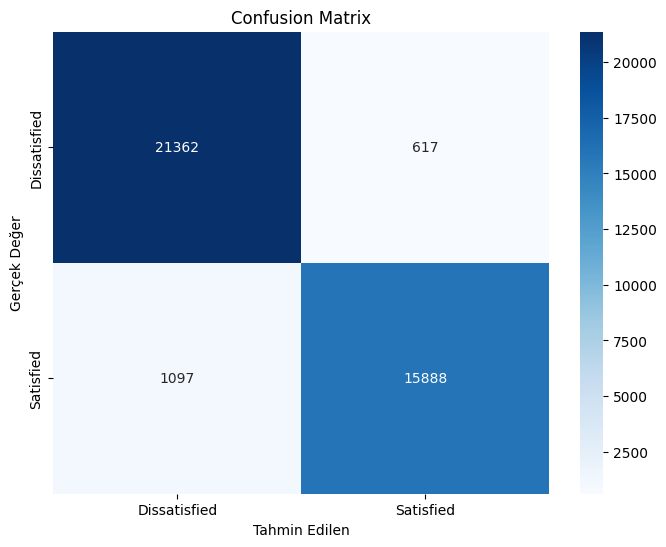

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=["Dissatisfied", "Satisfied"],
            yticklabels=["Dissatisfied", "Satisfied"])

plt.title("Confusion Matrix")
plt.ylabel("Gerçek Değer")
plt.xlabel("Tahmin Edilen")
plt.show()

In [64]:
import pickle
features_main = X_train.columns.tolist()
pickle.dump({
    "model": model,
    "scaler": minmax_scaler,
    "features": features_main
}, open("model_ysa.pkl", "wb"))

## Test

In [65]:
import pickle

dosyalar = {
    "Genetik":       r"model_genetic.pkl",
    "YSA":           r"model_ysa.pkl",
    "Decision Tree": r"model_decision_trees_gini.pkl",
    "Bernoulli NB":  r"model_brn.pkl",
}

for name, path in dosyalar.items():
    loaded = pickle.load(open(path, "rb"))
    scaler_n = loaded['scaler'].n_features_in_
    
    model = loaded['model']
    if hasattr(model, 'n_features_in_'):
        model_n = model.n_features_in_
    else:
        # YSA için input shape'e bak
        model_n = model.input_shape[-1]
    
    print(f"{name} — Scaler: {scaler_n} | Model: {model_n}")

Genetik — Scaler: 9 | Model: 9
YSA — Scaler: 22 | Model: 22
Decision Tree — Scaler: 22 | Model: 22
Bernoulli NB — Scaler: 22 | Model: 22


In [66]:
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

train_data=pd.read_csv(r"data/train.csv")
test_data=pd.read_csv(r"data/test.csv")

all_data = pd.concat((
    train_data.loc[:, "Gender":"satisfaction"],
    test_data.loc[:,  "Gender":"satisfaction"]
)).reset_index(drop=True)

all_data["Arrival Delay in Minutes"] = all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())

le = LabelEncoder()
all_data["satisfaction"] = le.fit_transform(all_data["satisfaction"].str.strip())
for col in ["Gender", "Customer Type", "Type of Travel", "Class"]:
    all_data[col] = le.fit_transform(all_data[col].str.strip())

x_raw = all_data.drop("satisfaction", axis=1)
y = all_data["satisfaction"]
_, x_Test, _, y_Test = train_test_split(x_raw, y, test_size=0.3, random_state=42)

dosyalar = {
    "YSA":           r"model_ysa.pkl",
    "Decision Tree": r"model_decision_trees_gini.pkl",
    "Bernoulli NB":  r"model_brn.pkl",
}

for name, path in dosyalar.items():
    loaded = pickle.load(open(path, "rb"))
    model  = loaded["model"]
    scaler = loaded["scaler"]
    feats  = loaded["features"]
    
    X_scaled = scaler.transform(x_Test[feats])
    p = model.predict(X_scaled)
    if hasattr(p, 'ndim') and (p.ndim > 1 or p.dtype != int):
        p = (p > 0.5).astype(int).flatten()
    
    print(f"{name} — Accuracy: {accuracy_score(y_Test, p):.4f} | Satisfied: {np.sum(p==1)} | Not Satisfied: {np.sum(p==0)}")

1218/1218 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step
YSA — Accuracy: 0.9560 | Satisfied: 16505 | Not Satisfied: 22459
Decision Tree — Accuracy: 0.8801 | Satisfied: 18344 | Not Satisfied: 20620
Bernoulli NB — Accuracy: 0.7751 | Satisfied: 18455 | Not Satisfied: 20509


In [67]:
import pickle
import pandas as pd
import numpy as np

# NOT SATISFIED olması gereken senaryo
input_dict = {
    "Gender": 0,              # Female
    "Customer Type": 1,       # disloyal
    "Age": 30,
    "Type of Travel": 1,      # Personal Travel
    "Class": 1,               # Eco
    "Flight Distance": 1000,
    "Inflight wifi service": 1,
    "Departure/Arrival time convenient": 1,
    "Ease of Online booking": 1,
    "Gate location": 1,
    "Food and drink": 1,
    "Online boarding": 1,
    "Seat comfort": 1,
    "Inflight entertainment": 1,
    "On-board service": 1,
    "Leg room service": 1,
    "Baggage handling": 1,
    "Checkin service": 1,
    "Inflight service": 1,
    "Cleanliness": 1,
    "Departure Delay in Minutes": 0,
    "Arrival Delay in Minutes": 0,
}

dosyalar = {
    "Genetik":       r"model_genetic.pkl",
    "YSA":           r"model_ysa.pkl",
    "Decision Tree": r"model_decision_trees_gini.pkl",
    "Bernoulli NB":  r"model_brn.pkl",
}

for name, path in dosyalar.items():
    loaded = pickle.load(open(path, "rb"))
    model  = loaded["model"]
    scaler = loaded["scaler"]
    feats  = loaded["features"]
    
    df = pd.DataFrame([input_dict])
    X_scaled = scaler.transform(df[feats])
    p = model.predict(X_scaled)
    if hasattr(p, 'ndim') and (p.ndim > 1 or p.dtype != int):
        p = (p > 0.5).astype(int).flatten()
    
    print(f"{name}: {'SATISFIED' if p[0]==1 else 'NOT SATISFIED'}")

Genetik: NOT SATISFIED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
YSA: NOT SATISFIED
Decision Tree: NOT SATISFIED
Bernoulli NB: NOT SATISFIED
